# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [24]:
# Author: Reza Tajvidi  
# Perspective: I’m framing this as a dealer deciding which vehicles to prioritize. 
#     I’ll focus on variables a buyer can see quickly (year, mileage, condition, title, brand/model) 
#     and keep the evaluation metric in dollars (MAE) for business interpretability.


# **Business Understanding (my focus):**
# - **Persona:** Used-car dealer in a metro area optimizing acquisition bids + listing prices.
# - **Region:** Assume mixed urban/suburban demand; trucks/SUVs may be regionally strong.
# - **Decisions:** Which cars to buy (and at what max bid), how to price them on day 0.
# - **KPI:** Dollar error (MAE) on price predictions and a rank-ordered list of value drivers.


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [25]:

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


# setting up the folders and paths
DATA_PATH = os.path.join("data", "vehicles.csv")
IMAGES_DIR = os.path.join("images")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
print("Setup complete.")


Setup complete.


In [26]:
# loading the data
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [27]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [37]:
# Summary stats for numeric cols
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
id,383638.0,7.311464e+09,4.475649e+06,7.207408e+09,7.308083e+09,7.312579e+09,7.315243e+09,7.317101e+09
price,383638.0,1.936155e+04,1.497019e+04,5.010000e+02,7.900000e+03,1.597000e+04,2.799000e+04,1.999990e+05
year,382466.0,2.010975e+03,9.602515e+00,1.900000e+03,2.008000e+03,2.013000e+03,2.017000e+03,2.022000e+03
odometer,381517.0,9.839272e+04,1.892407e+05,0.000000e+00,3.813000e+04,8.765600e+04,1.360000e+05,1.000000e+07


In [38]:
# Missing values snapshot
missing = df.isna().mean().sort_values(ascending=False).to_frame('missing_ratio')
missing.head(20)

,missing_ratio
size,0.718427
cylinders,0.407593
VIN,0.385754
condition,0.377890
drive,0.303580
paint_color,0.289163
type,0.214830
manufacturer,0.040027
title_status,0.018210
model,0.011761


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [32]:

# **My data assumptions & scope:**
# - I’ll trim extreme prices (<$500 or >$200k) to remove obvious data entry anomalies.
# - I’ll require `year` and `odometer` to model price because they are core to valuation.
# - High-cardinality categories (model/region) are collapsed to "other" to keep OHE tractable.
# - I understand this may drop some rare but high-value trims; trade-off is justified for a first pass.


# Few steps that I will take to prepare the data for modeling
# - Setting up the Target variable
# - Drop rows with non-positive or extreme target prices (basic outlier)
# - Candidate features selection
# - Keep only available columns
# - Drop rows with missing target; handle missing odometer/year minimally
# - For simplicity, drop rows missing both 'year' and 'odometer'
# - Reduce rare categories in high-cardinality columns to 'other'

# After these steps I should have a clean, smaller set of engineered 
# features ready for modeling and an initial set of visualizations 
# and summary statistics I can present to the client explaining
# which factors appear to drive price.

# Setting up the target variable
TARGET = "price"

# Drop rows with non-positive or extreme target prices (basic outlier)
df = df[(df[TARGET] > 500) & (df[TARGET] < 200000)]

# Candidate features selection
candidate_features = [
    "year","manufacturer","model","condition","cylinders","fuel","odometer",
    "title_status","transmission","drive","size","type","paint_color","state","region"
]

# Keep only available columns
features = [c for c in candidate_features if c in df.columns]
df_model = df[features + [TARGET]].copy()

In [39]:
# Simple cleaning: drop rows with missing target; handle missing odometer/year minimally
df_model = df_model.dropna(subset=[TARGET])

In [40]:
# For simplicity, drop rows missing both 'year' and 'odometer'
df_model = df_model.dropna(subset=['year','odometer'], how='any')

In [41]:
# Reduce rare categories in high-cardinality columns to 'other'
def collapse_rare(series, min_count=1000):
    counts = series.value_counts(dropna=False)
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), other="other")

for col in ["manufacturer","model","region"]:
    if col in df_model.columns:
        # slightly stricter to reduce OHE width
        df_model[col] = collapse_rare(df_model[col], min_count=2000)        


print(df_model.shape)
df_model.head()

(380407, 16)


,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,region,price
27,2014.0,gmc,other,good,8 cylinders,gas,57923.0,clean,other,NaN,NaN,pickup,white,al,other,33590
28,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,NaN,NaN,pickup,blue,al,other,22590
29,2020.0,chevrolet,other,good,8 cylinders,gas,19160.0,clean,other,NaN,NaN,pickup,red,al,other,39590
30,2017.0,toyota,other,good,8 cylinders,gas,41124.0,clean,other,NaN,NaN,pickup,red,al,other,30990
31,2013.0,ford,other,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,full-size,truck,black,al,other,15000


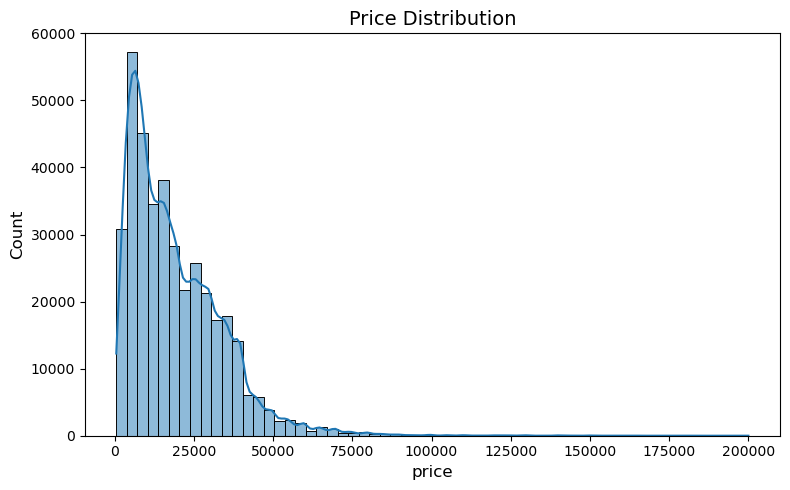

In [ ]:
# Looking at Price distribution
ax = sns.histplot(df_model[TARGET], bins=60, kde=True)
ax.set_title("Price Distribution")
ax.set_xlabel("price")
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "price_distribution.png"))
plt.show()

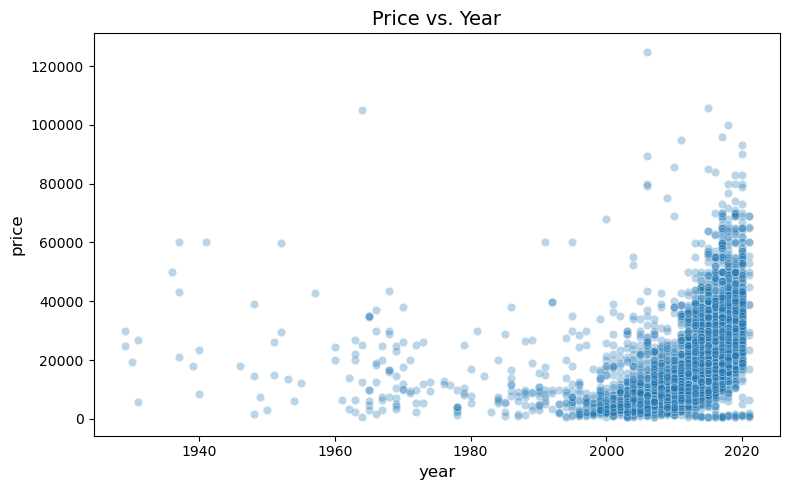

In [43]:
# Lookign at Price vs. Year
sample_df = df_model.sample(min(5000, len(df_model)), random_state=RANDOM_STATE)
ax = sns.scatterplot(data=sample_df, x="year", y=TARGET, alpha=0.3)
ax.set_title("Price vs. Year")
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "price_vs_year.png"))
plt.show()

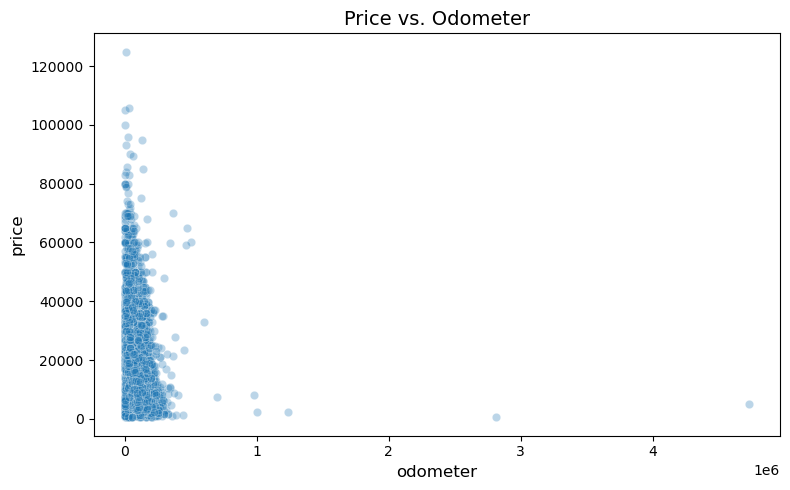

In [44]:
# Looking at Price vs. Odometer
sample_df = df_model.sample(min(5000, len(df_model)), random_state=RANDOM_STATE)
ax = sns.scatterplot(data=sample_df, x="odometer", y=TARGET, alpha=0.3)
ax.set_title("Price vs. Odometer")
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "price_vs_odometer.png"))
plt.show()

In [45]:
print("Data preparation and initial EDA complete.")
print("Price is biased toward newer, lower-mileage cars as expected.")

Data preparation and initial EDA complete.
Price is biased toward newer, lower-mileage cars as expected.


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.